- Develop a Monte Carlo simulation to estimate option prices.
- Simulate random price paths for the underlying asset using geometric Brownian motion.
- Calculate option payoffs and average them to estimate option prices.
- Compare results with theoretical values from the Black-Scholes model.
- Apply the model to price Bermudan options.
- Analyze the impact of the number of simulations on the accuracy of the results.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Develop a Monte Carlo simulation to estimate option prices.
def monte_carlo_simulation(S0, K, T, r, sigma, n_simulations, n_steps):
  dt = T / n_steps
  price_paths = np.zeros((n_simulations, n_steps + 1))
  price_paths[:,0] = S0

  for i in range(1, n_steps+1):
    z = np.random.standard_normal(n_simulations)
    price_paths[:,i] = price_paths[:,i-1] * np.exp((r - 0.5 * sigma ** 2) * dt + sigma * np.sqrt(dt) * z)

  return price_paths

def estimate_price(S0, K, T, r, sigma, n_simulations, n_steps, option_type = "call"):
    price_paths = monte_carlo_simulation(S0, K, T, r, sigma, n_simulations, n_steps)
    S_T = price_paths[:, -1]  # prices @ Maturity
    if option_type == "call":
      payoffs = np.maximum(0, S_T - K)
    if option_type == "put":
      payoffs = np.maximum(0, K - S_T)
    payoffs_discounted = np.exp(-r * T) * payoffs
    call_price = np.mean(payoffs_discounted)
    return price_paths, call_price

def plot_price_paths(price_paths):
  plt.figure(figsize=(10, 6))
  for i in range(len(price_paths)):
      plt.plot(price_paths[i])

  plt.title("Monte Carlo Simulated Price Paths")
  plt.xlabel("Time Steps")
  plt.ylabel("Price")
  plt.grid(True)
  plt.legend(loc='upper left', ncol=2, fontsize='small')
  plt.show()

from scipy.stats import norm
def black_scholes(S0, K, T, r, sigma, option_type = "call"):
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == "call":
        price = S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    elif option_type == "put":
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S0 * norm.cdf(-d1)
    return price

In [ ]:
# Parameters
S0 = 100    # Initial stock price
K = 100     # Strike price
T = 1       # Time to maturity in years
r = 0.05    # Risk-free rate
sigma = 0.20 # Volatility
n_simulations = 100
n_steps = 10

In [ ]:
price_bs = black_scholes(S0, K, T, r, sigma)
print(f"BSM Model Price : {price_bs}")

BSM Model Price : 10.450583572185565


In [ ]:
n = 8

price_paths_arr = []
call_price_arr = []
simulation = []

for i in range(1,n):
  n_simulations = 10**i
  price_paths, call_price = estimate_price(S0, K, T, r, sigma, n_simulations, n_steps)
  print(f"Simulations : {n_simulations}  Estimated price : {call_price}")

  price_paths_arr.append(price_paths)
  call_price_arr.append(call_price)
  simulation.append(n_simulations)

Simulations : 10  Estimated price : 3.476856184073276
Simulations : 100  Estimated price : 12.9522611346769
Simulations : 1000  Estimated price : 10.819348621673209
Simulations : 10000  Estimated price : 10.354846909567469
Simulations : 100000  Estimated price : 10.497037278734659
Simulations : 1000000  Estimated price : 10.461254797106664
Simulations : 10000000  Estimated price : 10.459242008096766


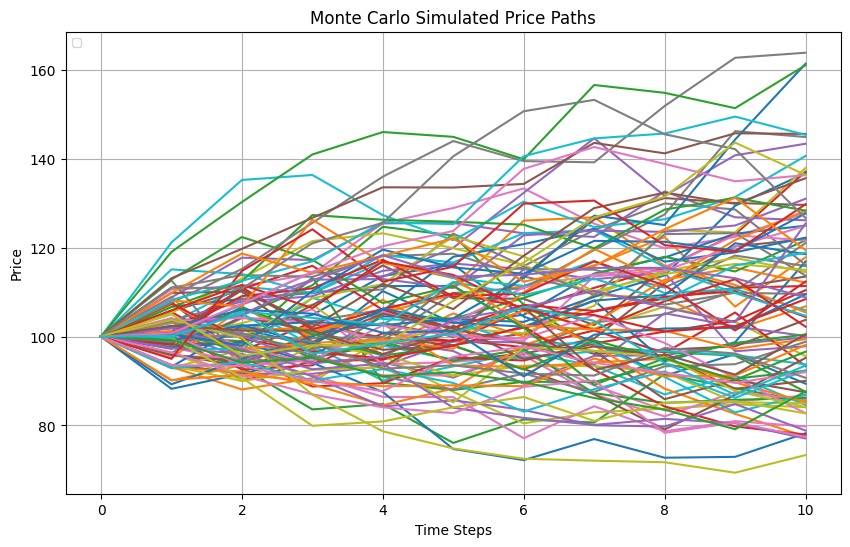

In [ ]:
plot_price_paths(price_paths_arr[1])

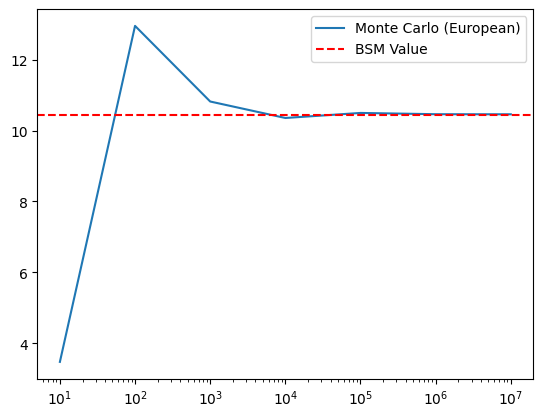

In [ ]:
plt.plot(simulation, call_price_arr, label = 'Monte Carlo (European)')
plt.axhline(y = price_bs, color='r', linestyle='--', label='BSM Value')
plt.xscale('log')
plt.legend()
plt.show()

American

In [ ]:
from numpy.polynomial.polynomial import Polynomial
def american_option_pricing(S0, K, T, r, sigma, num_simulations, num_steps, option_type="call"):
    dt = T / num_steps
    price_paths = monte_carlo_simulation(S0, K, T, r, sigma, num_simulations, num_steps)

    # Initialize cashflows at maturity
    if option_type == "call":
        cashflows = np.maximum(price_paths[:, -1] - K, 0)
    elif option_type == "put":
        cashflows = np.maximum(K - price_paths[:, -1], 0)

    # Work backward through the tree
    for t in reversed(range(1, num_steps)):
      intrinsic_values = np.maximum(0, (price_paths[:, t] - K) if option_type == "call" else (K - price_paths[:, t]))
      in_the_money = intrinsic_values > 0
      # Y = F(X) gives expected continuation value @ t where X = stock price @ t and Y = value of option @ t+1 discounted to t
      X = price_paths[in_the_money,t]
      Y = cashflows[in_the_money] * np.exp(-r * dt)
      if len(X) > 0:
            regression_coeffs = np.polyfit(X, Y, deg=2)  # Fit a quadratic polynomial
            continuation_estimates = np.polyval(regression_coeffs, X)
            cashflows[in_the_money] = np.where(intrinsic_values[in_the_money] > continuation_estimates,intrinsic_values[in_the_money], Y)


    # Discount back to present value and average
    option_price = np.exp(-r * dt) * np.mean(cashflows)
    return option_price

In [ ]:
n = 8

call_price_american = []
simulation_american = []

for i in range(1,n):
  n_simulations = 10**i
  call_price = american_option_pricing(S0, K, T, r, sigma, n_simulations, n_steps)
  print(f"Simulations : {n_simulations}  Estimated price : {call_price}")

  call_price_american.append(call_price)
  simulation_american.append(n_simulations)

Simulations : 10  Estimated price : 16.461113085577942
Simulations : 100  Estimated price : 10.540524810155496
Simulations : 1000  Estimated price : 10.68742701129659
Simulations : 10000  Estimated price : 10.521801122465062
Simulations : 100000  Estimated price : 10.539307628863392
Simulations : 1000000  Estimated price : 10.51321606206801
Simulations : 10000000  Estimated price : 10.517117788107997


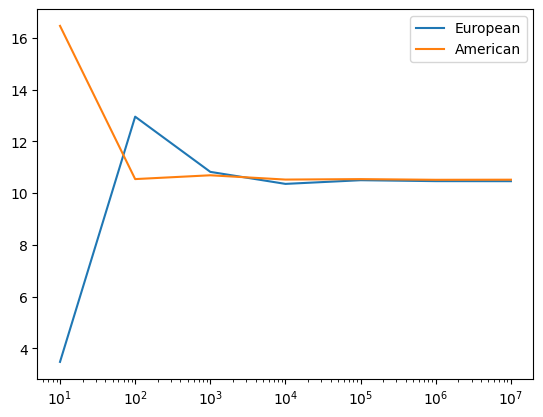

In [ ]:
plt.plot(simulation, call_price_arr, label = 'European')
plt.plot(simulation, call_price_american, label = 'American')

# plt.axhline(y = prices_sim[-1], color='r', linestyle='--', label='BSM Value')
plt.xscale('log')
plt.legend()
plt.show()

In [ ]:
# simulation = [10**i for i in range(1,5)]

def bermudan_option_pricing(S0, K, T, r, sigma, num_simulations, num_steps, exercise_dates, option_type="call"):
    dt = T / num_steps
    price_paths = monte_carlo_simulation(S0, K, T, r, sigma, num_simulations, num_steps)

    # Initialize cashflows at maturity
    if option_type == "call":
        cashflows = np.maximum(price_paths[:, -1] - K, 0)
    elif option_type == "put":
        cashflows = np.maximum(K - price_paths[:, -1], 0)

    # Backward induction for early exercise
    for t in reversed(range(num_steps - 1)):
        time = t * dt
        if time in exercise_dates:
            intrinsic_values = np.maximum(0, (price_paths[:, t] - K) if option_type == "call" else (K - price_paths[:, t]))
            in_the_money = intrinsic_values > 0

            # Continuation value estimation via regression
            X = price_paths[in_the_money, t]
            Y = cashflows[in_the_money] * np.exp(-r * dt)
            if len(X) > 0:
                regression_coeffs = np.polyfit(X, Y, deg=2)
                continuation_estimates = np.polyval(regression_coeffs, X)
                cashflows[in_the_money] = np.where(intrinsic_values[in_the_money] > continuation_estimates,
                                                   intrinsic_values[in_the_money], Y)
        # Discount cashflows
        cashflows *= np.exp(-r * dt)

    option_price = np.mean(cashflows)
    return option_price


prices_sim = []
for i in range(1,8):
  n_simulations = 10**i
  call_price = bermudan_option_pricing(S0, K, T, r, sigma, n_simulations, n_steps, [.3,.5,.7,1])
  prices_sim.append(call_price)
  print(f"Simulations : {n_simulations}  Estimated price : {call_price}")

Simulations : 10  Estimated price : 6.9208960977022205
Simulations : 100  Estimated price : 9.160824158379194
Simulations : 1000  Estimated price : 10.347790001637106
Simulations : 10000  Estimated price : 10.576559001166387
Simulations : 100000  Estimated price : 10.46083737431803
Simulations : 1000000  Estimated price : 10.468247786544348
Simulations : 10000000  Estimated price : 10.461025074407567


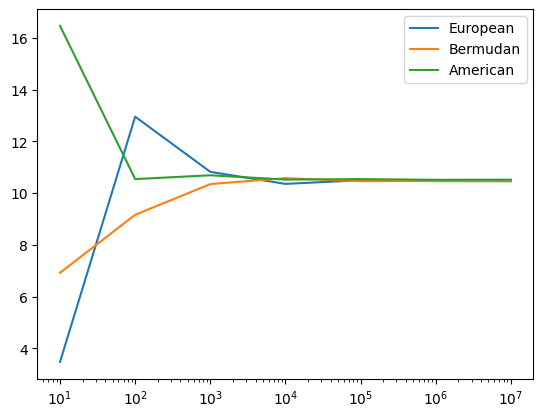

In [ ]:
plt.plot(simulation, call_price_arr, label = 'European')
plt.plot(simulation, prices_sim, label = 'Bermudan')
plt.plot(simulation, call_price_american, label = 'American')

# plt.axhline(y = prices_sim[-1], color='r', linestyle='--', label='BSM Value')
plt.xscale('log')
plt.legend()
plt.show()

Put

In [ ]:
price_bs = black_scholes(S0, K, T, r, sigma,"put")
print(f"BSM Model Price : {price_bs}")

BSM Model Price : 5.573526022256971


In [ ]:
n = 8

price_paths_arr = []
put_price_european = []
simulation = []

for i in range(1,n):
  n_simulations = 10**i
  price_paths, put_price = estimate_price(S0, K, T, r, sigma, n_simulations, n_steps,"put")
  print(f"Simulations : {n_simulations}  Estimated price : {put_price}")

  price_paths_arr.append(price_paths)
  put_price_european.append(put_price)
  simulation.append(n_simulations)

Simulations : 10  Estimated price : 8.167625457789377
Simulations : 100  Estimated price : 6.011128664318111
Simulations : 1000  Estimated price : 5.197582725974183
Simulations : 10000  Estimated price : 5.477811840587726
Simulations : 100000  Estimated price : 5.61128602467276
Simulations : 1000000  Estimated price : 5.565680445950301
Simulations : 10000000  Estimated price : 5.571363529823912


In [ ]:
n = 8

put_price_american = []
simulation_american = []

for i in range(1,n):
  n_simulations = 10**i
  put_price = american_option_pricing(S0, K, T, r, sigma, n_simulations, n_steps,"put")
  print(f"Simulations : {n_simulations}  Estimated price : {put_price}")

  put_price_american.append(put_price)
  simulation_american.append(n_simulations)

<ipython-input-27-ef60cae69780>:20: RankWarning: Polyfit may be poorly conditioned
  regression_coeffs = np.polyfit(X, Y, deg=2)  # Fit a quadratic polynomial
<ipython-input-27-ef60cae69780>:20: RankWarning: Polyfit may be poorly conditioned
  regression_coeffs = np.polyfit(X, Y, deg=2)  # Fit a quadratic polynomial
<ipython-input-27-ef60cae69780>:20: RankWarning: Polyfit may be poorly conditioned
  regression_coeffs = np.polyfit(X, Y, deg=2)  # Fit a quadratic polynomial
<ipython-input-27-ef60cae69780>:20: RankWarning: Polyfit may be poorly conditioned
  regression_coeffs = np.polyfit(X, Y, deg=2)  # Fit a quadratic polynomial


Simulations : 10  Estimated price : 7.486376910908961
Simulations : 100  Estimated price : 6.136360101681849
Simulations : 1000  Estimated price : 6.251820354995417
Simulations : 10000  Estimated price : 6.164339893816188
Simulations : 100000  Estimated price : 6.054236558277833
Simulations : 1000000  Estimated price : 6.067708418217132
Simulations : 10000000  Estimated price : 6.071085289468906


In [ ]:
put_price_bermudan = []
for i in range(1,8):
  n_simulations = 10**i
  put_price = bermudan_option_pricing(S0, K, T, r, sigma, n_simulations, n_steps, [.3,.5,.7,1],"put")
  put_price_bermudan.append(put_price)
  print(f"Simulations : {n_simulations}  Estimated price : {put_price}")

Simulations : 10  Estimated price : 5.295916247437002
Simulations : 100  Estimated price : 6.244466288875525
Simulations : 1000  Estimated price : 5.340049006340509
Simulations : 10000  Estimated price : 5.825635789882331
Simulations : 100000  Estimated price : 5.842375219456365
Simulations : 1000000  Estimated price : 5.8397867252144735
Simulations : 10000000  Estimated price : 5.82853936910427


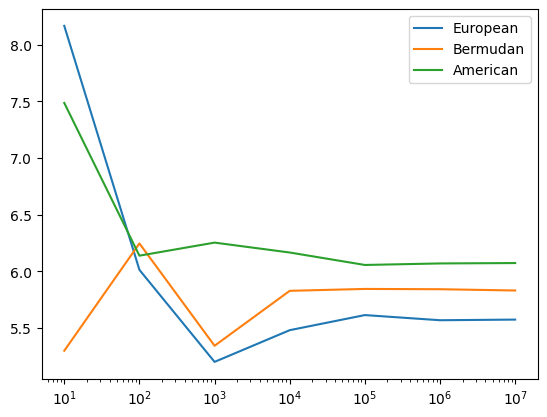

In [ ]:
plt.plot(simulation, put_price_european, label = 'European')
plt.plot(simulation, put_price_bermudan, label = 'Bermudan')
plt.plot(simulation, put_price_american, label = 'American')

# plt.axhline(y = prices_sim[-1], color='r', linestyle='--', label='BSM Value')
plt.xscale('log')
plt.legend()
plt.show()